# UK Fruit & Vegetable Wholesale Price EDA

Weekly national average wholesale prices collected from Birmingham, Manchester, London, and Bristol markets (DEFRA). Data covers **2015–2026**.

Each subplot shows the raw weekly price (thin line) and a **4-week rolling average** (thick line).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 9

DATA = 'data/'

In [2]:
def parse_fruitveg_sheet(ods_file, sheet_name):
    raw = pd.read_excel(ods_file, sheet_name=sheet_name, header=None, engine='odf')
    date_row, data_start = None, None
    for i in range(min(20, len(raw))):
        if any('commodity' in str(v).lower() for v in raw.iloc[i]):
            data_start = i + 1
            date_row   = i - 2
            break
    if date_row is None:
        date_row, data_start = 11, 14
    dates, dcols = [], []
    for c in range(5, raw.shape[1]):
        v = raw.iloc[date_row, c]
        if pd.notna(v):
            try:
                dates.append(pd.to_datetime(v))
                dcols.append(c)
            except Exception:
                pass
    if not dates:
        return pd.DataFrame()
    records = []
    for r in range(data_start, raw.shape[0]):
        row  = raw.iloc[r]
        ct   = row.iloc[1] if pd.notna(row.iloc[1]) else None
        sc   = row.iloc[2] if pd.notna(row.iloc[2]) else None
        var  = row.iloc[3] if pd.notna(row.iloc[3]) else None
        unit = row.iloc[4] if pd.notna(row.iloc[4]) else None
        if ct is None and sc is None and var is None:
            continue
        for date, c in zip(dates, dcols):
            p = row.iloc[c]
            if pd.notna(p):
                try:
                    records.append({'date': date, 'commodity_type': ct,
                                    'sub_category': sc, 'variety': var,
                                    'unit': unit, 'price': float(p)})
                except (ValueError, TypeError):
                    pass
    return pd.DataFrame(records)

ods_file = DATA + 'fruitveg-weeklyhort-260216.ods'
sheets   = ['2016-2015','2017-2016','2017','2018','2019','2020',
            '2021','2022','2023','2024','2025','2026']

fv = pd.concat([parse_fruitveg_sheet(ods_file, s) for s in sheets], ignore_index=True)
fv['commodity_type'] = fv['commodity_type'].ffill()
fv['sub_category']   = fv['sub_category'].ffill()
fv = fv.drop_duplicates(subset=['date','commodity_type','sub_category','variety'])
fv = fv.sort_values('date').reset_index(drop=True)

print(f"Loaded {len(fv):,} rows  |  {fv['date'].min().date()} → {fv['date'].max().date()}")

Loaded 26,448 rows  |  2015-01-09 → 2026-02-16


In [3]:
import re

GENERIC = {'fruit', 'vegetable', 'cut flowers', 'pot plants'}
VEG_OVERRIDE = {'tomato', 'rhubarb'}
FLOWER_KW = {'flower','chrysanth','tulip','gladiol','narciss','alstrom',
             'begonia','cyclamen','iris','pink','poinsett','lily','lilies','oriental'}
FRUIT_KW  = {'apple','pear','strawberr','raspberr','cherri','plum','damson',
             'gooseberr','currant','blueberr'}
META_PATTERNS = {'(a)','(b)','(c)','(d)','(e)','(f)','from 1','with effect',
                 'no part','source:','note','footnote','revisions','figures',
                 'data collect','data for','collection of','price collection'}

def is_metadata(val):
    v = str(val).lower().strip()
    return any(v.startswith(p) for p in META_PATTERNS) or len(v) > 120

def classify(row):
    ct = str(row['commodity_type']).strip()
    if is_metadata(ct): return 'Other'
    tokens = ' '.join([ct, str(row['sub_category']), str(row['variety'])]).lower()
    if any(k in tokens for k in VEG_OVERRIDE): return 'Vegetable'
    if any(k in tokens for k in FLOWER_KW):    return 'Other'
    if ct.lower() == 'fruit':                  return 'Fruit'
    if any(k in tokens for k in FRUIT_KW):     return 'Fruit'
    return 'Vegetable'

fv['type'] = fv.apply(classify, axis=1)

def clean_name(name):
    return re.sub(r'\s*\([a-z]\)\s*$', '', str(name).strip())

def is_apple_row(row):
    return 'apple' in ' '.join([str(row['commodity_type']), str(row['sub_category']),
                                 str(row['variety'])]).lower()

def apple_display_name(row):
    tokens = ' '.join([str(row['commodity_type']), str(row['sub_category']),
                       str(row['variety'])]).lower()
    return 'Cooking Apples' if any(k in tokens for k in {'bramley','cooking apple'}) else 'Dessert Apples'

def is_onion_row(row):
    ct = str(row['commodity_type']).strip().lower()
    sc = str(row['sub_category']).strip().lower()
    return ct in ('bulb onions', 'salad onions') or (ct == 'vegetable' and sc == 'onion')

def onion_display_name(row):
    # DEFRA restructured their sheets in November 2017: pre-2017 onions live under
    # commodity_type='Bulb Onions'/'Salad Onions'; post-2017 all onion rows are under
    # commodity_type='Vegetable', sub_category='Onion', differentiated only by variety.
    # Without this handler the two periods produce separate, broken half-series.
    ct  = str(row['commodity_type']).strip().lower()
    sc  = str(row['sub_category']).strip().lower()
    var = str(row['variety']).strip().lower()
    if ct == 'salad onions' or 'salad' in var or 'spring' in var:
        return 'Salad Onions'
    if sc == 'yellow' or 'brown' in var:
        return 'Bulb Onions (Yellow)'
    if sc == 'red' or 'red' in var:
        return 'Bulb Onions (Red)'
    return 'Bulb Onions'

def is_capsicum_row(row):
    ct = str(row['commodity_type']).strip().lower()
    sc = str(row['sub_category']).strip().lower()
    return ct == 'capsicums' or (ct == 'vegetable' and sc == 'capsicum')

def capsicum_display_name(row):
    # Same Nov 2017 schema change as onions: pre-2017 capsicums live under
    # commodity_type='Capsicums' with colour in sub_category; post-2017 they are
    # under commodity_type='Vegetable', sub_category='Capsicum', colour in variety.
    ct  = str(row['commodity_type']).strip().lower()
    sc  = str(row['sub_category']).strip().lower()
    var = str(row['variety']).strip().lower()
    colour = sc if ct == 'capsicums' else var
    if 'red' in colour:                        return 'Capsicums (Red)'
    if 'green' in colour:                      return 'Capsicums (Green)'
    if 'yellow' in colour or 'orange' in colour: return 'Capsicums (Yellow/Orange)'
    if 'elongat' in colour:                    return 'Capsicums (Elongated)'
    return 'Capsicums'

def is_tomato_row(row):
    ct = str(row['commodity_type']).strip().lower()
    sc = str(row['sub_category']).strip().lower()
    return ct == 'tomatoes' or (ct == 'vegetable' and sc == 'tomatoes')

def tomato_display_name(row):
    # Same Nov 2017 schema change: pre-2017 variety is in sub_category under
    # commodity_type='Tomatoes'; post-2017 it is in variety under
    # commodity_type='Vegetable', sub_category='Tomatoes'.
    # Splitting by variety avoids averaging cherry tomatoes (£2–3/kg) with
    # round tomatoes (£0.4–0.8/kg) into a meaningless blended price.
    ct  = str(row['commodity_type']).strip().lower()
    sc  = str(row['sub_category']).strip().lower()
    var = str(row['variety']).strip().lower()
    variety = sc if ct == 'tomatoes' else var
    if 'round'  in variety: return 'Tomatoes (Round)'
    if 'vine'   in variety: return 'Tomatoes (Vine)'
    if 'cherry' in variety: return 'Tomatoes (Cherry)'
    if 'plum'   in variety: return 'Tomatoes (Plum)'
    return 'Tomatoes'

def display_name(row):
    ct = str(row['commodity_type']).strip()
    sc = str(row['sub_category']).strip()
    if is_metadata(ct):        return 'Other'
    if is_apple_row(row):      return apple_display_name(row)
    if is_onion_row(row):      return onion_display_name(row)
    if is_capsicum_row(row):   return capsicum_display_name(row)
    if is_tomato_row(row):     return tomato_display_name(row)
    if ct.lower() in GENERIC:
        raw = sc if sc not in ('nan', '', '-') else ct
    else:
        raw = ct
    return clean_name(raw)

fv['display_name'] = fv.apply(display_name, axis=1)

for t in ['Fruit', 'Vegetable']:
    names = sorted(fv[fv['type'] == t]['display_name'].unique())
    print(f"{t} ({len(names)}): {names}")

Fruit (15): ['Blackberries', 'Blackcurrants', 'Blueberries', 'Cherries', 'Cooking Apples', 'Currants', 'Damsons', 'Dessert Apples', 'Gooseberries', 'Pears', 'Plums', 'Plums and Gages', 'Raspberries', 'Redcurrants', 'Strawberries']
Vegetable (44): ['Asparagus', 'Beans', 'Beetroot', 'Broad Beans', 'Brussels Sprouts', 'Bulb Onions (Red)', 'Bulb Onions (Yellow)', 'Cabbage', 'Calabrese', 'Capsicums (Elongated)', 'Capsicums (Green)', 'Capsicums (Red)', 'Capsicums (Yellow/Orange)', 'Carrots', 'Celeriac', 'Celery', 'Chinese leaf', 'Coriander', 'Courgettes', 'Cucumbers', 'Curly kale', 'Dwarf, French or Kidney Beans', 'Geranium', 'Leeks', 'Lettuce', 'Mixed babyleaf salad', 'Pak choi', 'Parsnips', 'Peas', 'Rhubarb', 'Rocket', 'Runner Beans', 'Salad Onions', 'Shelling Peas', 'Spinach leaf', 'Spring greens', 'Swede', 'Sweetcorn', 'Tomatoes (Cherry)', 'Tomatoes (Plum)', 'Tomatoes (Round)', 'Tomatoes (Vine)', 'Turnip', 'Watercress']


In [4]:
# Pre-2017 sheets report three grade rows per date ('1st', '2nd', 'Ave') for some
# commodities. Keeping all three would inflate the weekly mean, so only 'Ave' is
# retained. Post-2017 sheets have no grade column and are unaffected.
EXPLICIT_GRADES = {'1st', '2nd'}
GRADE_DEDUP_NAMES = {
    'Cooking Apples', 'Dessert Apples',
    'Capsicums (Red)', 'Capsicums (Green)',
    'Tomatoes (Round)', 'Tomatoes (Vine)', 'Tomatoes (Cherry)', 'Tomatoes (Plum)',
}

dedup_mask  = fv['display_name'].isin(GRADE_DEDUP_NAMES)
non_dedup   = fv[~dedup_mask]
dedup_clean = fv[dedup_mask & ~fv['variety'].astype(str).str.strip().isin(EXPLICIT_GRADES)]
fv_clean    = pd.concat([non_dedup, dedup_clean], ignore_index=True)

weekly = (fv_clean[fv_clean['type'].isin(['Fruit', 'Vegetable'])]
          .groupby(['type', 'display_name', 'date'])['price']
          .mean()
          .reset_index()
          .sort_values('date'))

print(f"fv_clean: {len(fv_clean):,} rows  |  weekly: {len(weekly):,} obs "
      f"across {weekly['display_name'].nunique()} commodities")

fv_clean: 24,754 rows  |  weekly: 15,881 obs across 59 commodities


In [5]:
full_weeks = pd.date_range(fv['date'].min(), fv['date'].max(), freq='W')
N_FULL = len(full_weeks)

miss = (weekly.groupby(['type', 'display_name'])
              .apply(lambda g: 100.0 * (1 - len(g) / N_FULL))
              .reset_index(name='missing_pct')
              .sort_values(['type', 'missing_pct']))

print(f"Full week count: {N_FULL}\n")
for t in ['Fruit', 'Vegetable']:
    sub = miss[miss['type'] == t]
    print(f"{t}:")
    for _, row in sub.iterrows():
        bar = '█' * int((100 - row['missing_pct']) / 5)
        print(f"  {row['display_name']:<30} {row['missing_pct']:5.1f}% missing  {bar}")
    print()

Full week count: 580

Fruit:
  Cooking Apples                   9.3% missing  ██████████████████
  Dessert Apples                  15.5% missing  ████████████████
  Pears                           28.6% missing  ██████████████
  Strawberries                    38.8% missing  ████████████
  Raspberries                     53.6% missing  █████████
  Blackberries                    75.9% missing  ████
  Blueberries                     75.9% missing  ████
  Cherries                        78.4% missing  ████
  Gooseberries                    81.6% missing  ███
  Plums                           82.9% missing  ███
  Currants                        87.2% missing  ██
  Plums and Gages                 95.5% missing  
  Blackcurrants                   95.7% missing  
  Damsons                         96.4% missing  
  Redcurrants                     97.6% missing  

Vegetable:
  Cabbage                          9.1% missing  ██████████████████
  Beetroot                         9.3% missing  ███

In [6]:
ROLL = 4  # weeks for rolling average

## Selected Commodities (20)

Focused subset combining fruit and vegetables, plotted in alphabetical order:
Asparagus, Beetroot, Bulb Onions (Red & Yellow), Cabbage, Capsicums (Green & Red), Carrots,
Cooking Apples, Cucumbers, Curly kale, Dessert Apples, Leeks, Lettuce, Pak choi,
Pears, Spring greens, Strawberries, Tomatoes (Round & Vine).

Note: Asparagus is a highly seasonal crop (UK season: late March – late June), so ~69% missing is expected.

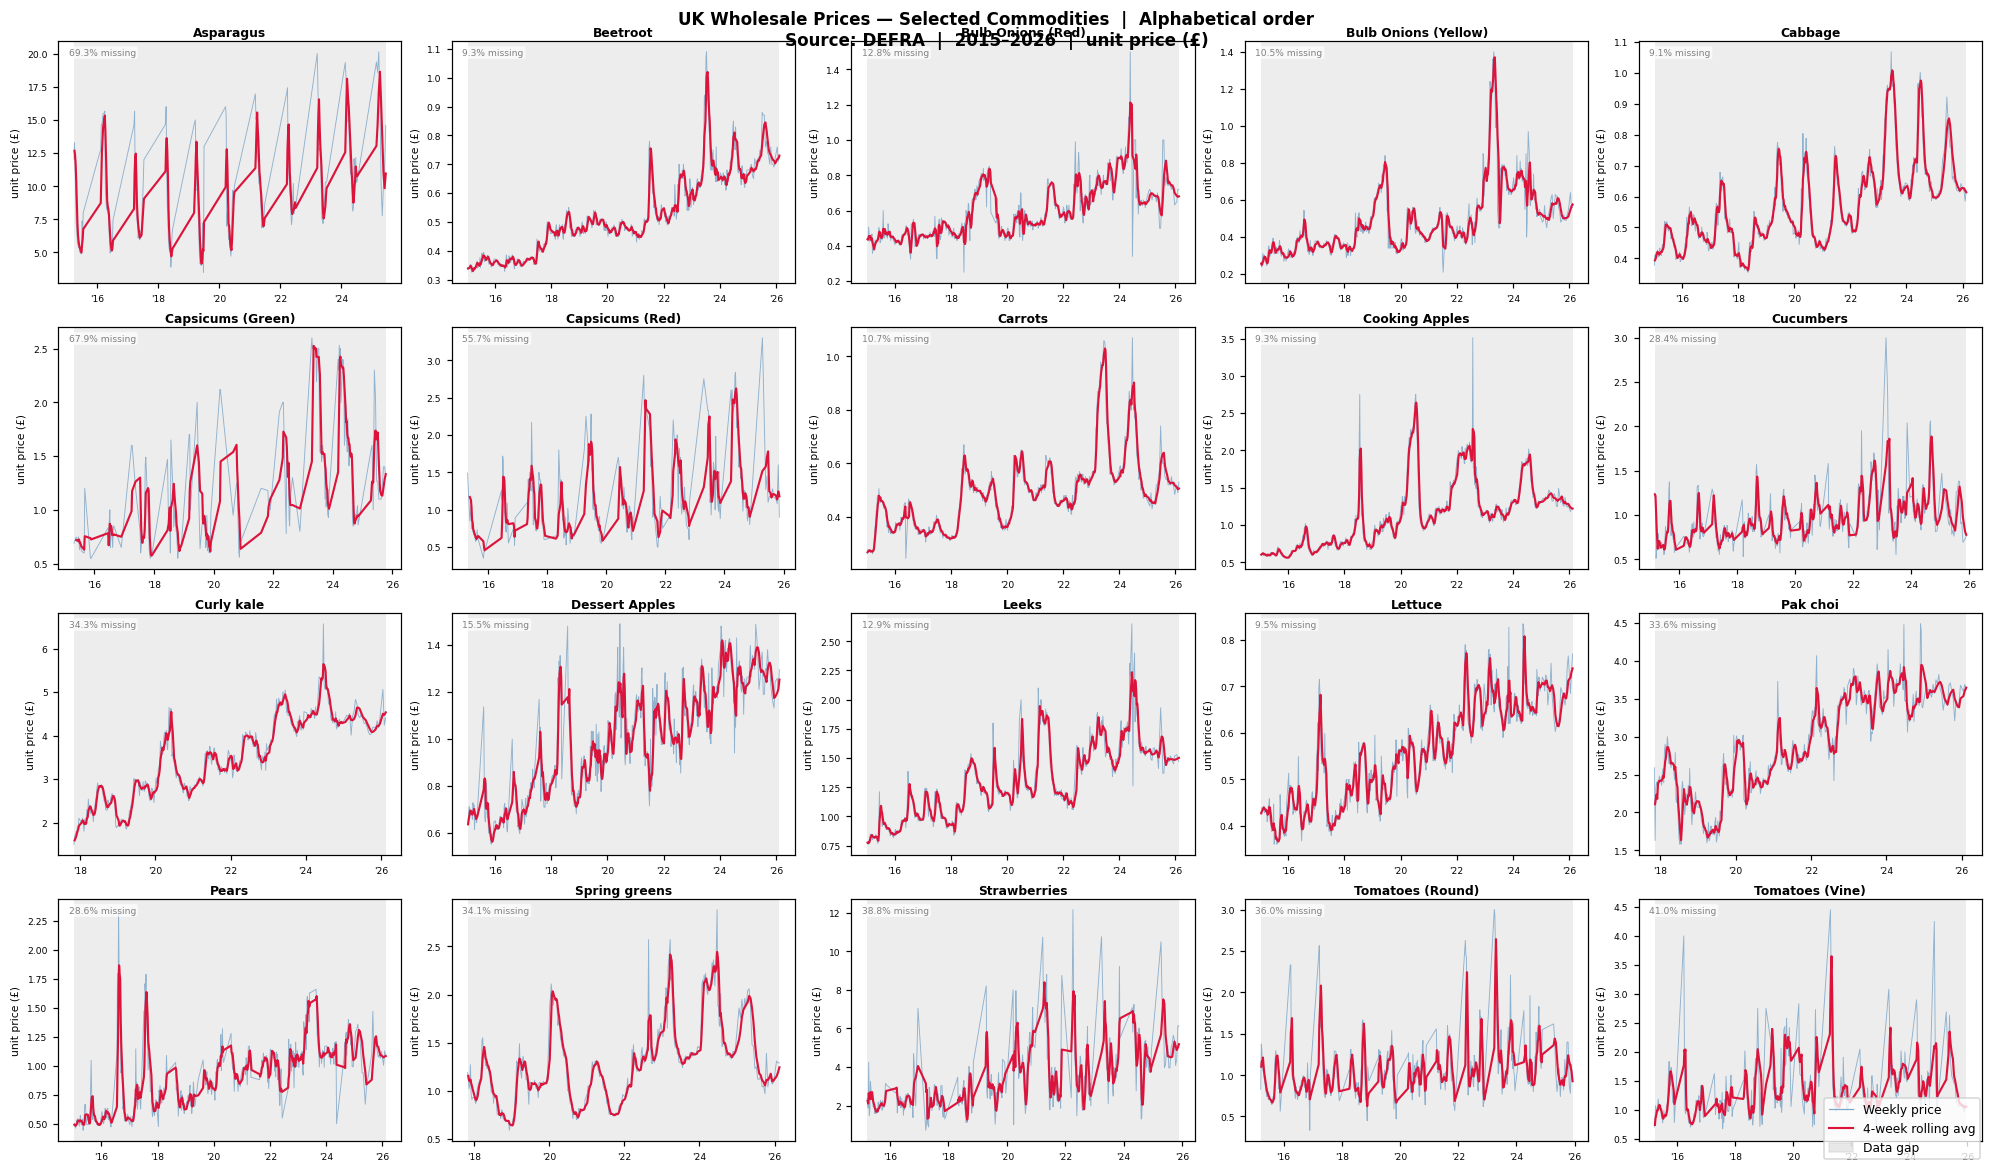

Plotted 20 commodities


In [7]:
SELECTED = sorted([
    'Asparagus',
    'Beetroot',
    'Bulb Onions (Red)',
    'Bulb Onions (Yellow)',
    'Cabbage',
    'Capsicums (Green)',
    'Capsicums (Red)',
    'Carrots',
    'Cooking Apples',
    'Cucumbers',
    'Curly kale',
    'Dessert Apples',
    'Leeks',
    'Lettuce',
    'Pak choi',
    'Pears',
    'Spring greens',
    'Strawberries',
    'Tomatoes (Round)',
    'Tomatoes (Vine)',
])

subset = weekly[weekly['display_name'].isin(SELECTED)].copy()
n      = len(SELECTED)
ncols  = 5
nrows  = (n + ncols - 1) // ncols

color      = 'steelblue'
roll_color = 'crimson'

# Full weekly date range for computing missing %
full_weeks_sel = pd.date_range(fv['date'].min(), fv['date'].max(), freq='W')
N_FULL_SEL     = len(full_weeks_sel)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3.6, nrows * 2.6),
                         constrained_layout=True)
axes_flat = np.array(axes).flatten()

for ax, name in zip(axes_flat, SELECTED):
    s    = subset[subset['display_name'] == name].set_index('date')['price'].sort_index()
    roll = s.rolling(ROLL, min_periods=2).mean()

    ax.plot(s.index, s.values, color=color, linewidth=0.6, alpha=0.55)
    ax.plot(roll.index, roll.values, color=roll_color, linewidth=1.4)

    ax.set_title(name, fontsize=8, fontweight='bold', pad=3)
    ax.set_ylabel('unit price (£)', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

    # missing % annotation
    missing_pct = 100.0 * (1 - len(s) / N_FULL_SEL)
    ax.text(0.03, 0.97, f'{missing_pct:.1f}% missing',
            transform=ax.transAxes, fontsize=6,
            va='top', ha='left', color='grey',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

    # shade data gaps
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq='W')
    s_reindexed = s.reindex(full_idx)
    in_gap, gap_start = False, None
    for dt, val in s_reindexed.items():
        if pd.isna(val) and not in_gap:
            in_gap, gap_start = True, dt
        elif not pd.isna(val) and in_gap:
            ax.axvspan(gap_start, dt, color='lightgrey', alpha=0.4, lw=0)
            in_gap = False
    if in_gap:
        ax.axvspan(gap_start, s_reindexed.index[-1], color='lightgrey', alpha=0.4, lw=0)

for ax in axes_flat[n:]:
    ax.set_visible(False)

handles = [
    plt.Line2D([0],[0], color=color,     linewidth=0.8, alpha=0.7, label='Weekly price'),
    plt.Line2D([0],[0], color=roll_color, linewidth=1.4,            label='4-week rolling avg'),
    plt.Rectangle((0,0),1,1, color='lightgrey', alpha=0.5,          label='Data gap'),
]
fig.legend(handles=handles, loc='lower right',
           bbox_to_anchor=(1.0, 0.0), fontsize=8, frameon=True)

fig.suptitle(
    'UK Wholesale Prices — Selected Commodities  |  Alphabetical order\n'
    'Source: DEFRA  |  2015–2026  |  unit price (£)',
    fontsize=11, fontweight='bold', y=1.01
)
plt.show()
print(f"Plotted {n} commodities")

In [8]:
out = (weekly[weekly['display_name'].isin(SELECTED)]
       [['date', 'display_name', 'price']]
       .sort_values(['display_name', 'date'])
       .reset_index(drop=True))

out.to_csv(DATA + 'cleaned_fruit_veg.csv', index=False)
print(f"Saved {len(out):,} rows × {out.shape[1]} cols  →  {DATA}cleaned_fruit_veg.csv")
print(f"Commodities: {sorted(out['display_name'].unique())}")
print(out.head())

Saved 8,308 rows × 3 cols  →  data/cleaned_fruit_veg.csv
Commodities: ['Asparagus', 'Beetroot', 'Bulb Onions (Red)', 'Bulb Onions (Yellow)', 'Cabbage', 'Capsicums (Green)', 'Capsicums (Red)', 'Carrots', 'Cooking Apples', 'Cucumbers', 'Curly kale', 'Dessert Apples', 'Leeks', 'Lettuce', 'Pak choi', 'Pears', 'Spring greens', 'Strawberries', 'Tomatoes (Round)', 'Tomatoes (Vine)']
        date display_name      price
0 2015-03-27    Asparagus  12.045714
1 2015-04-03    Asparagus  13.295238
2 2015-04-10    Asparagus  11.712195
3 2015-04-17    Asparagus   9.517053
4 2015-04-24    Asparagus   7.117590
